# Setup

This project requires Python 3.7 or above:

In [3]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [4]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

And TensorFlow ≥ 2.8:

In [5]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [6]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [29]:
import numpy as np
from pathlib import Path

# Ejercicio 10

Entrena un MLP profundo en el conjunto de datos MNIST.
- Intenta alcanzar más del 98% de precisión ajustando manualmente los hiperparámetros.
- Busca la tasa de aprendizaje óptima
  - Incrementando la tasa de aprendizaje de manera exponencial
  - Graficando la pérdida
  - Encontrando el punto en el que la pérdida aumenta drásticamente.
- Ajusta los hiperparámetros utilizando Keras Tuner con todas las características avanzadas:
  - Guarda checkpoints
  - Utiliza early stopping
  - Grafica las curvas de aprendizaje con TensorBoard.  

**TODO**: Actualizar esta solución para utilizar Keras Tuner.




## Cargar el dataset

In [7]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


El conjunto de entrenamiento MNIST contiene 60.000 imágenes en escala de grises, cada una de 28x28 píxeles:

In [8]:
X_train_full.shape

(60000, 28, 28)

La intensidad de cada píxel también se representa como un byte (de 0 a 255):

In [9]:
X_train_full.dtype

dtype('uint8')

Vamos a dividir el conjunto de entrenamiento completo en un conjunto de validación y un conjunto de entrenamiento (más pequeño).

También reducimos las intensidades de los píxeles al rango 0-1 y las convertimos en flotantes, dividiéndolas por 255:

In [10]:
X_valid, X_train = X_train_full[:5000] / 255., X_train_full[5000:] / 255.
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.

Vamos a graficar una imagen utilizando la función `imshow()` de Matplotlib, con un mapa de colores `'binary'`:

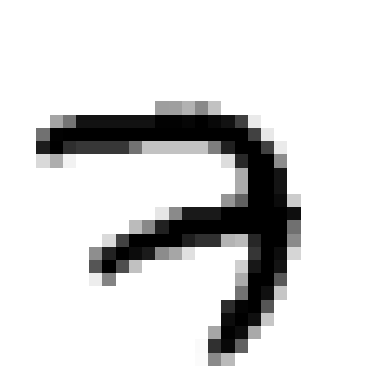

In [11]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

Las etiquetas son los IDs de las clases (representados como uint8), que van del 0 al 9. De manera conveniente, los IDs de las clases corresponden a los dígitos representados en las imágenes, por lo que no necesitamos un array de `class_names`:

In [12]:
y_train

array([7, 3, 4, ..., 5, 6, 8], dtype=uint8)

El conjunto de validación contiene 5.000 imágenes y el conjunto de prueba, 10.000:

In [13]:
X_valid.shape

(5000, 28, 28)

In [14]:
X_test.shape

(10000, 28, 28)

Veamos una muestra de las imágenes del conjunto de datos:

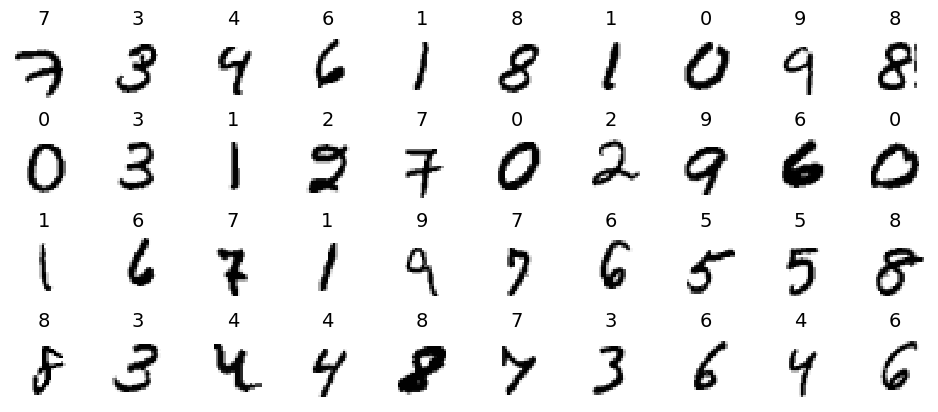

In [15]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(y_train[index])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

## Construir la red neuronal

Construyamos una red densa simple y encontremos la tasa de aprendizaje óptima.

### Definir callback para la tasa de aprendizaje

Necesitaremos una llamada de retorno (callback) para aumentar la tasa de aprendizaje en cada iteración. También registrará la tasa de aprendizaje y la pérdida en cada iteración:

In [16]:
# Asignar el backend de Keras a la variable K
K = tf.keras.backend

class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor # Factor para aumentar la tasa de aprendizaje
        self.rates = []      # Lista para almacenar las tasas de aprendizaje en cada batch
        self.losses = []     # Lista para almacenar las pérdidas en cada batch

    def on_batch_end(self, batch, logs=None):
        # Incrementar la tasa de aprendizaje multiplicándola por el factor
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        # Asignar la nueva tasa de aprendizaje al optimizador
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)            # Guardar la tasa de aprendizaje en la lista
        self.losses.append(logs["loss"]) # Guardar la pérdida en la lista

### Definir el Modelo

Con todas las capas necesarias.

In [20]:
# Limpiar cualquier sesión anterior de Keras
tf.keras.backend.clear_session()
# Establecer semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

In [21]:
# Definición del modelo secuencial de Keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # Aplanar las imágenes 28x28 en vectores de 784 elementos
    tf.keras.layers.Dense(300, activation="relu"),  # Capa densa con 300 neuronas y activación ReLU
    tf.keras.layers.Dense(100, activation="relu"),  # Capa densa con 100 neuronas y activación ReLU
    tf.keras.layers.Dense(10, activation="softmax") # Capa de salida con 10 neuronas y activación softmax para clasificación multiclase
])

### Compilar el Modelo

En Keras, debes llamar a `compile()` antes de `fit()` porque el proceso de **compilación** establece cómo el modelo va a ser entrenado, qué funciones de pérdida y optimizadores utilizar, y qué métricas vas a monitorizar. Es decir, `compile()` prepara el modelo para el entrenamiento.

Empezaremos con una pequeña tasa de aprendizaje de 1e-3, y la aumentaremos un 0,5% en cada iteración:

In [22]:
# Definir el optimizador SGD con una tasa de aprendizaje inicial de 1e-3
optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

# Crear una instancia del callback ExponentialLearningRate con un factor de crecimiento de 1.005
expon_lr = ExponentialLearningRate(factor=1.005)

### Entrenar el Modelo para ajustar la Tasa de Aprendizaje

Ahora vamos a entrenar el modelo para una sola época, utilizando el callback de `ExponentialLearningRate` para ajustar la tasa de aprendizaje y registrar los cambios.


In [23]:
# Entrenar el modelo con los datos de entrenamiento y validación, utilizando el callback exponencial
history = model.fit(X_train, y_train, epochs=1,
                    validation_data=(X_valid, y_valid),
                    callbacks=[expon_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5135 - loss: nan - val_accuracy: 0.0958 - val_loss: nan


Ahora podemos representar la pérdida en función de la tasa de aprendizaje:

Text(0, 0.5, 'Loss')

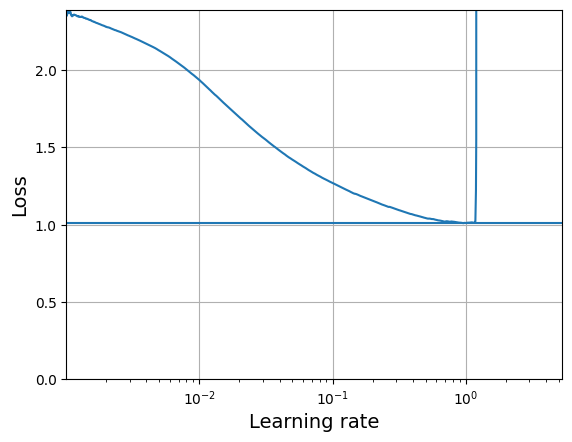

In [24]:
# Graficar la tasa de aprendizaje frente a la pérdida
plt.plot(expon_lr.rates, expon_lr.losses)
plt.gca().set_xscale('log')  # Escala logarítmica en el eje x
plt.hlines(min(expon_lr.losses), min(expon_lr.rates), max(expon_lr.rates))
plt.axis([min(expon_lr.rates), max(expon_lr.rates), 0, expon_lr.losses[0]])
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

### Compilar y Entrenar el Modelo definitivo

La pérdida empieza a dispararse violentamente cuando la tasa de aprendizaje supera los 6e-1, así que probemos a utilizar la mitad, a 3e-1:

In [25]:
# Limpiar cualquier sesión anterior de Keras y establecer semillas para reproducibilidad
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

In [26]:
# Definir nuevamente el modelo secuencial de Keras
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),  # Aplanar las imágenes 28x28 en vectores de 784 elementos
    tf.keras.layers.Dense(300, activation="relu"),  # Capa densa con 300 neuronas y activación ReLU
    tf.keras.layers.Dense(100, activation="relu"),  # Capa densa con 100 neuronas y activación ReLU
    tf.keras.layers.Dense(10, activation="softmax") # Capa de salida con 10 neuronas y activación softmax para clasificación multiclase
])

In [27]:
# Definir un optimizador SGD con una tasa de aprendizaje de 3e-1
optimizer = tf.keras.optimizers.SGD(learning_rate=3e-1)

# Compilar el modelo con la función de pérdida sparse_categorical_crossentropy y el optimizador definido
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])

In [30]:
# Establecer el índice de ejecución del modelo y definir el directorio de logs
run_index = 1 # Incrementar este valor con cada ejecución
run_logdir = Path() / "my_mnist_logs" / "run_{:03d}".format(run_index)  # Ruta para almacenar los logs de ejecución
run_logdir

PosixPath('my_mnist_logs/run_001')

Se crean tres callbacks adicionales:
- `EarlyStopping` para detener el entrenamiento si la pérdida no mejora.
- `ModelCheckpoint` para guardar el mejor modelo.
- `TensorBoard` para registrar información de entrenamiento en un directorio de logs.

Se entrena el modelo durante 100 épocas, utilizando los callbacks definidos.

In [31]:
# Crear un callback de EarlyStopping que detendrá el entrenamiento si la pérdida no mejora durante 20 épocas
early_stopping_cb = tf.keras.callbacks.EarlyStopping(patience=20)

# Crear un callback de ModelCheckpoint que guardará el modelo con la mejor puntuación de validación
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint("my_mnist_model.keras", save_best_only=True)

# Crear un callback de TensorBoard para registrar información de entrenamiento en un directorio de logs
tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir)

# Entrenar el modelo durante 100 épocas, utilizando los callbacks definidos para guardar el mejor modelo, detener temprano y registrar en TensorBoard
history = model.fit(X_train, y_train, epochs=100,
                    validation_data=(X_valid, y_valid),
                    callbacks=[checkpoint_cb, early_stopping_cb, tensorboard_cb])

Epoch 1/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8638 - loss: 0.4267 - val_accuracy: 0.9694 - val_loss: 0.1052
Epoch 2/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9693 - loss: 0.1015 - val_accuracy: 0.9750 - val_loss: 0.0826
Epoch 3/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9821 - loss: 0.0628 - val_accuracy: 0.9792 - val_loss: 0.0797
Epoch 4/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9867 - loss: 0.0443 - val_accuracy: 0.9778 - val_loss: 0.0883
Epoch 5/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9891 - loss: 0.0339 - val_accuracy: 0.9780 - val_loss: 0.0844
Epoch 6/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9913 - loss: 0.0284 - val_accuracy: 0.9804 - val_loss: 0.0958
Epoch 7/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9928 - loss: 0.0219 - val_accuracy: 0.9802 - val_loss: 0.0836
Epoch 8/100
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9943 - loss:

### Recuperación y evaluación del mejor modelo

Se carga el mejor modelo guardado durante el entrenamiento y se evalúa con los datos de prueba.

In [32]:
# Cargar el mejor modelo guardado durante el entrenamiento (el que obtuvo la mejor puntuación de validación)
model = tf.keras.models.load_model("my_mnist_model.keras") # rollback al mejor modelo

# Evaluar el modelo cargado con los datos de prueba
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9695 - loss: 0.1129


[0.08852672576904297, 0.9753999710083008]

Obtuvimos más de un 98% de precisión.

### TensorBoard

Por último, veamos las curvas de aprendizaje utilizando TensorBoard:

In [33]:
%tensorboard --logdir=./my_mnist_logs

UsageError: Line magic function `%tensorboard` not found.
